In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path.home() / "projekty" / "dzietnosc-polska"
df = pd.read_csv(ROOT / "data" / "raw" / "bdl_polska.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   rok                       31 non-null     int64  
 1   tfr                       24 non-null     float64
 2   urodzenia_zywe            31 non-null     int64  
 3   zgony                     31 non-null     int64  
 4   ludnosc_przedprodukcyjna  31 non-null     int64  
 5   ludnosc_produkcyjna       31 non-null     int64  
 6   ludnosc_poprodukcyjna     31 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 1.8 KB


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

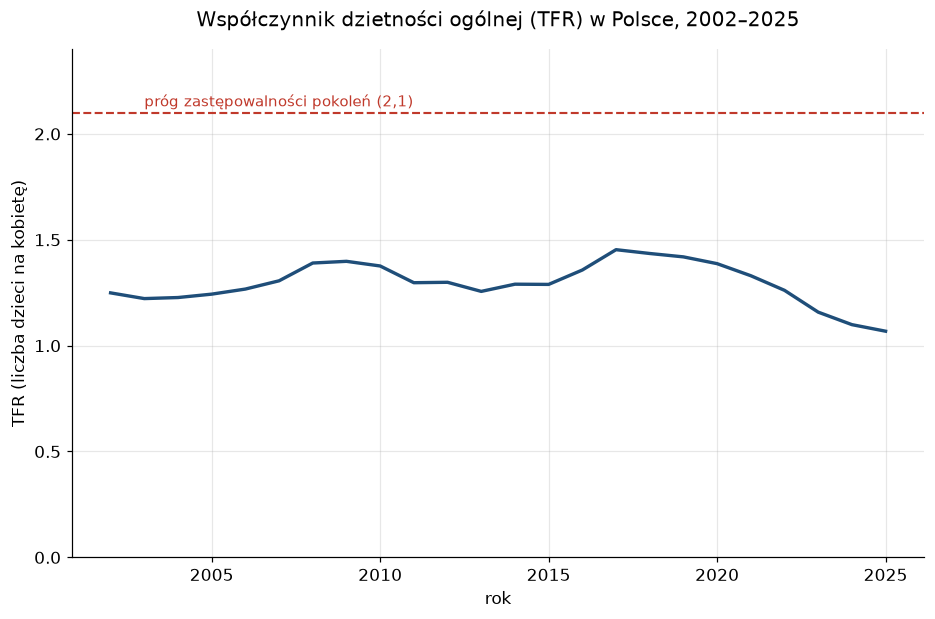

In [3]:
fig, ax = plt.subplots()

ax.plot(df["rok"], df["tfr"], color="#1f4e79", linewidth=2.2)

ax.axhline(2.1, color="#c0392b", linestyle="--", linewidth=1.4)

ax.text(2003, 2.13, "próg zastępowalności pokoleń (2,1)",
        color="#c0392b", fontsize=10)

ax.set_title("Współczynnik dzietności ogólnej (TFR) w Polsce, 2002–2025",
             fontsize=13, pad=15)
ax.set_xlabel("rok")
ax.set_ylabel("TFR (liczba dzieci na kobietę)")
ax.set_ylim(0, 2.4)

fig.savefig(ROOT / "figures" / "01_tfr_polska.png", dpi=200, bbox_inches="tight")

plt.show()

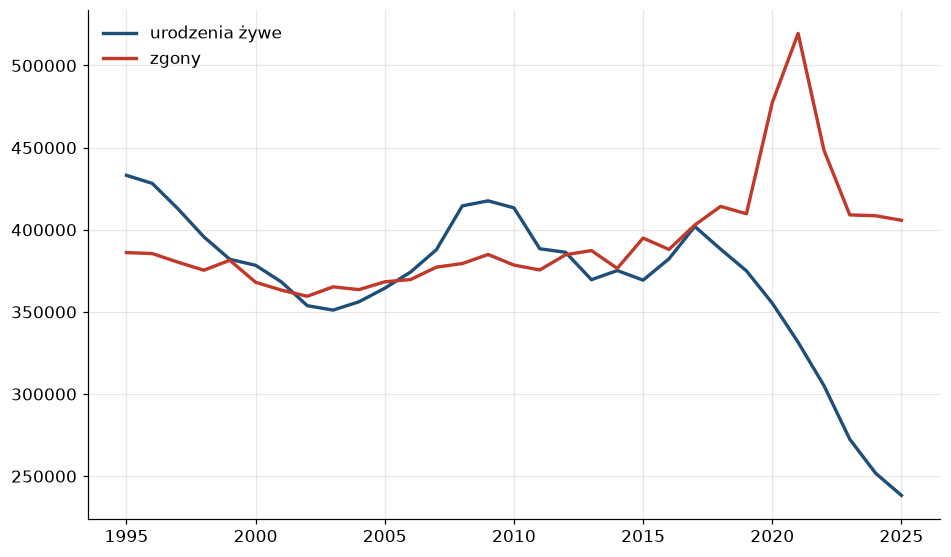

In [4]:
fig, ax = plt.subplots()

ax.plot(df["rok"], df["urodzenia_zywe"], color="#1f4e79",
        linewidth=2.2, label="urodzenia żywe")
ax.plot(df["rok"], df["zgony"], color="#c0392b",
        linewidth=2.2, label="zgony")

ax.legend(frameon=False)

plt.show()

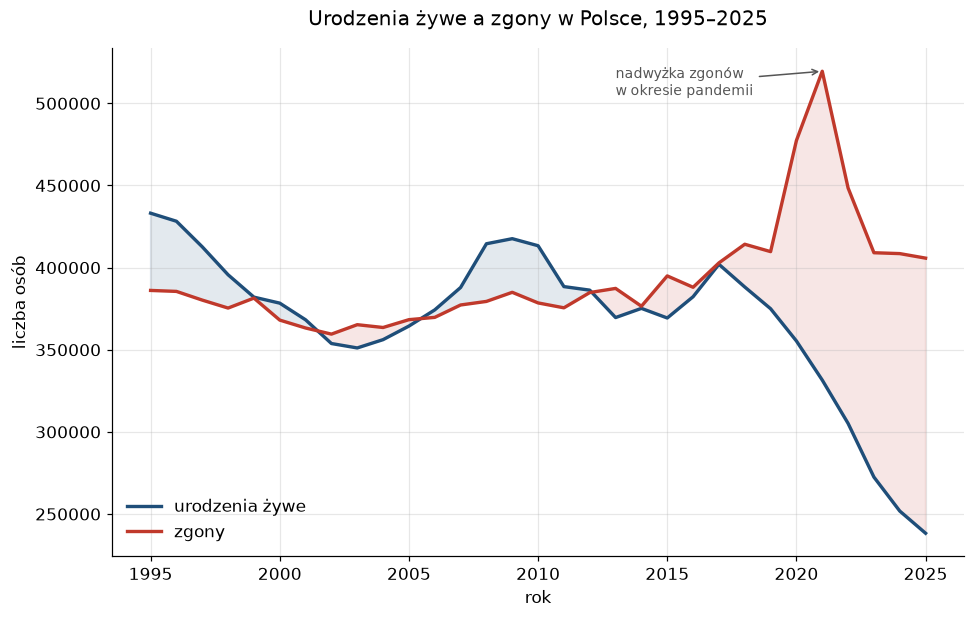

In [6]:
fig, ax = plt.subplots()

ax.fill_between(df["rok"], df["urodzenia_zywe"], df["zgony"],
                where=df["urodzenia_zywe"] >= df["zgony"],
                color="#1f4e79", alpha=0.12, interpolate=True)
ax.fill_between(df["rok"], df["urodzenia_zywe"], df["zgony"],
                where=df["urodzenia_zywe"] < df["zgony"],
                color="#c0392b", alpha=0.12, interpolate=True)

ax.plot(df["rok"], df["urodzenia_zywe"], color="#1f4e79",
        linewidth=2.2, label="urodzenia żywe")
ax.plot(df["rok"], df["zgony"], color="#c0392b",
        linewidth=2.2, label="zgony")

ax.annotate("nadwyżka zgonów\nw okresie pandemii",
            xy=(2021, 519517), xytext=(2013, 505000),
            fontsize=9, color="#555555",
            arrowprops=dict(arrowstyle="->", color="#555555", lw=1))

ax.set_title("Urodzenia żywe a zgony w Polsce, 1995–2025",
             fontsize=13, pad=15)
ax.set_xlabel("rok")
ax.set_ylabel("liczba osób")
ax.legend(frameon=False, loc="lower left")

fig.savefig(ROOT / "figures" / "02_urodzenia_zgony.png",
            dpi=200, bbox_inches="tight")

plt.show()

In [7]:
df["ludnosc_ogolem"] = (df["ludnosc_przedprodukcyjna"]
                        + df["ludnosc_produkcyjna"]
                        + df["ludnosc_poprodukcyjna"])

for grupa in ["przedprodukcyjna", "produkcyjna", "poprodukcyjna"]:
    df[f"udzial_{grupa}"] = (df[f"ludnosc_{grupa}"]
                             / df["ludnosc_ogolem"] * 100)

df[["rok", "udzial_przedprodukcyjna",
    "udzial_produkcyjna", "udzial_poprodukcyjna"]].head()

,rok,udzial_przedprodukcyjna,udzial_produkcyjna,udzial_poprodukcyjna
0,1995,27.570497,58.657782,13.771722
1,1996,26.960908,59.058937,13.980156
2,1997,26.294732,59.529192,14.176076
3,1998,25.573849,60.067627,14.358524
4,1999,25.167856,60.217196,14.614948


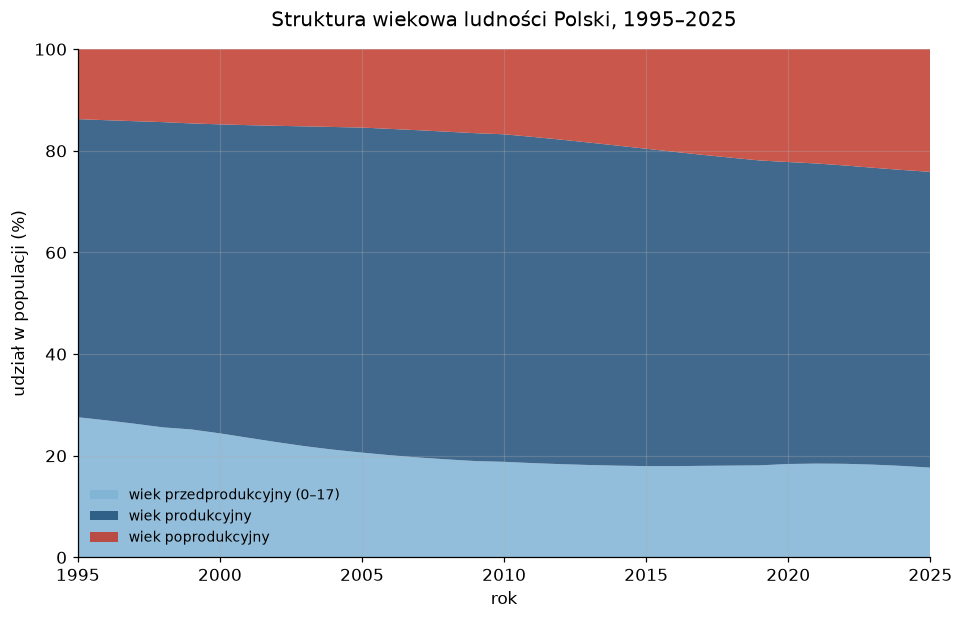

In [8]:
fig, ax = plt.subplots()

ax.stackplot(df["rok"],
             df["udzial_przedprodukcyjna"],
             df["udzial_produkcyjna"],
             df["udzial_poprodukcyjna"],
             labels=["wiek przedprodukcyjny (0–17)",
                     "wiek produkcyjny",
                     "wiek poprodukcyjny"],
             colors=["#7fb3d5", "#1f4e79", "#c0392b"],
             alpha=0.85)

ax.set_title("Struktura wiekowa ludności Polski, 1995–2025",
             fontsize=13, pad=15)
ax.set_xlabel("rok")
ax.set_ylabel("udział w populacji (%)")
ax.set_ylim(0, 100)
ax.set_xlim(1995, 2025)
ax.legend(frameon=False, loc="lower left", fontsize=9)

fig.savefig(ROOT / "figures" / "03_struktura_wiekowa.png",
            dpi=200, bbox_inches="tight")

plt.show()

In [9]:
df["obciazenie_starosc"] = (df["ludnosc_poprodukcyjna"]
                            / df["ludnosc_produkcyjna"] * 100)

df["obciazenie_calkowite"] = ((df["ludnosc_przedprodukcyjna"]
                               + df["ludnosc_poprodukcyjna"])
                              / df["ludnosc_produkcyjna"] * 100)

df[["rok", "obciazenie_starosc", "obciazenie_calkowite"]].iloc[[0, 15, 30]]

,rok,obciazenie_starosc,obciazenie_calkowite
0,1995,23.478081,70.480364
15,2010,25.998251,55.168396
30,2025,41.486115,71.822609


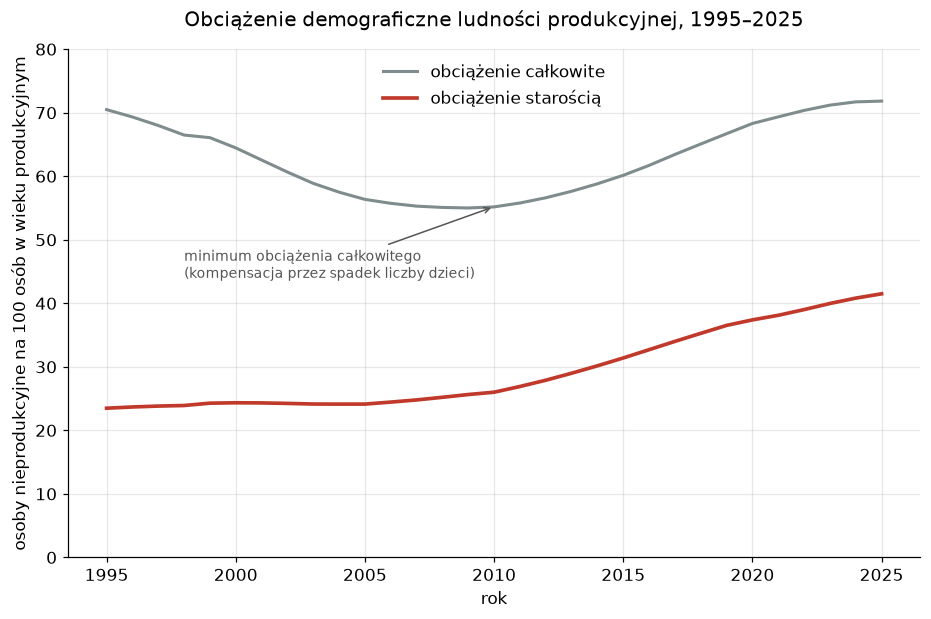

In [10]:
fig, ax = plt.subplots()

ax.plot(df["rok"], df["obciazenie_calkowite"], color="#7f8c8d",
        linewidth=2.0, linestyle="-", label="obciążenie całkowite")
ax.plot(df["rok"], df["obciazenie_starosc"], color="#c0392b",
        linewidth=2.4, label="obciążenie starością")

ax.annotate("minimum obciążenia całkowitego\n(kompensacja przez spadek liczby dzieci)",
            xy=(2010, 55.2), xytext=(1998, 44),
            fontsize=9, color="#555555",
            arrowprops=dict(arrowstyle="->", color="#555555", lw=1))

ax.set_title("Obciążenie demograficzne ludności produkcyjnej, 1995–2025",
             fontsize=13, pad=15)
ax.set_xlabel("rok")
ax.set_ylabel("osoby nieprodukcyjne na 100 osób w wieku produkcyjnym")
ax.set_ylim(0, 80)
ax.legend(frameon=False, loc="upper center")

fig.savefig(ROOT / "figures" / "04_obciazenie_demograficzne.png",
            dpi=200, bbox_inches="tight")

plt.show()

In [11]:
kob = pd.read_csv(ROOT / "data" / "raw" / "kohorty_kobiet.csv", index_col="rok")
print(kob.columns.tolist())
print(kob.shape)

['15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49']
(31, 7)


In [12]:
KOHORTY = ["15-19", "20-24", "25-29", "30-34", "35-39", "40-44", "45-49"]
kob["razem"] = kob[KOHORTY].sum(axis=1)

kob[["15-19", "25-29", "45-49", "razem"]].iloc[[0, 15, 30]]

,15-19,25-29,45-49,razem
rok,,,,
1995,1584255,1201447,1380967,10052820
2010,1185934,1610901,1235301,9514328
2025,1002759,951279,1512092,8455859


In [23]:
print((KATALOG_FIG / "05_struktura_kohort.png").exists())
print((KATALOG_FIG / "05_struktura_kohort.png").stat().st_size)

True
94215


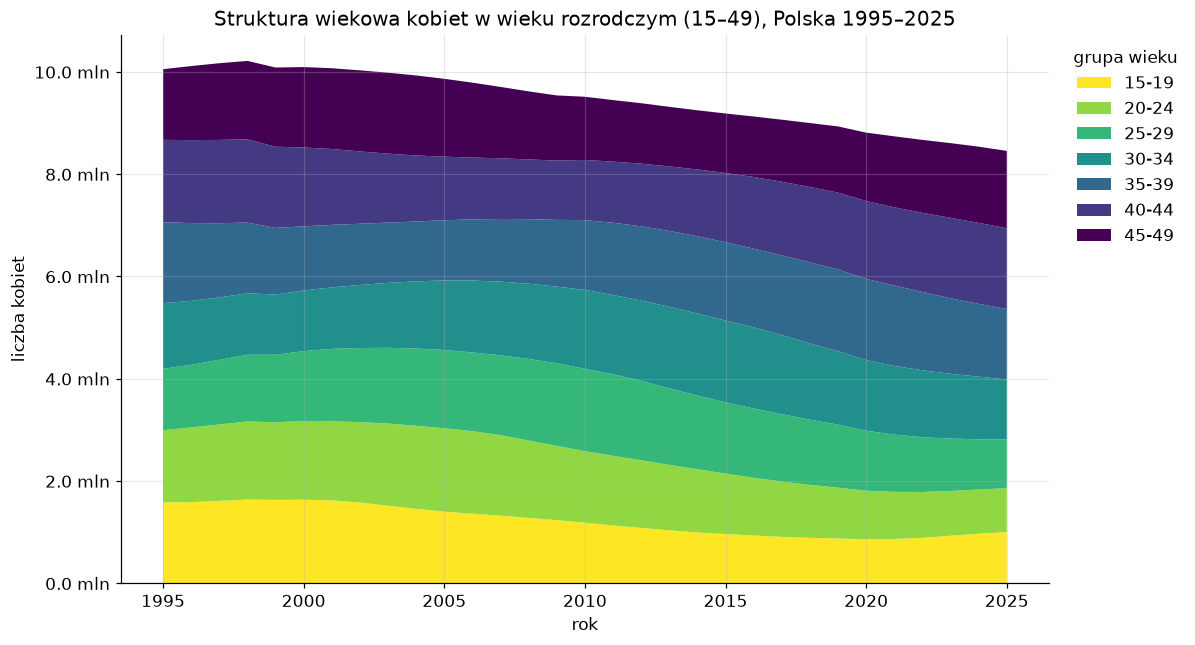

In [24]:
from matplotlib.ticker import FuncFormatter

kolory = plt.cm.viridis_r([i / (len(KOHORTY) - 1) for i in range(len(KOHORTY))])

fig, ax = plt.subplots(figsize=(11, 6))

ax.stackplot(
    kob.index,
    *[kob[k] for k in KOHORTY],
    labels=KOHORTY,
    colors=kolory,
)

ax.set_xlabel("rok")
ax.set_ylabel("liczba kobiet")
ax.set_title("Struktura wiekowa kobiet w wieku rozrodczym (15–49), Polska 1995–2025")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1e6:.1f} mln")
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    ncol=1,
    frameon=False,
    title="grupa wieku",
)

fig.tight_layout()
KATALOG_FIG = ROOT / "figures"
KATALOG_FIG.mkdir(exist_ok=True)

fig.savefig(
    KATALOG_FIG / "05_struktura_kohort.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [1]:
import pandas as pd
from pathlib import Path

BAZA = Path.home() / "projekty" / "dzietnosc-polska"

asfr = pd.read_csv(BAZA / "data" / "processed" / "asfr_polska_2002_2025.csv")

# Roczna zmiana laczna liczebnosci kobiet 15-49
koh = asfr.groupby("rok")["kobiety"].sum()
zmiana = koh.diff() / koh.shift()

# Reszta z kontroli TFR
bdl = pd.read_csv(BAZA / "data" / "raw" / "bdl_polska.csv").set_index("rok")
tfr_obl = asfr.groupby("rok")["asfr"].sum() * 5
reszta = (tfr_obl - bdl["tfr"]) / bdl["tfr"] * 100

test = pd.concat([zmiana.rename("zmiana_kohorty_%") * 100,
                  reszta.rename("reszta_%")], axis=1).dropna()
print(test.round(3).to_string())
print(f"\nKorelacja: {test.corr().iloc[0, 1]:.3f}")

      zmiana_kohorty_%  reszta_%
rok                             
2003            -0.458    -0.379
2004            -0.540    -0.368
2005            -0.659    -0.233
2006            -0.763     0.135
2007            -0.852     0.359
2008            -0.894     0.444
2009            -0.825     0.561
2010            -0.274     0.885
2011            -0.678     1.086
2012            -0.651     1.330
2013            -0.760     1.568
2014            -0.720     1.660
2015            -0.676     1.766
2016            -0.639     1.590
2017            -0.690     1.598
2018            -0.720     1.747
2019            -0.734     1.809
2020            -1.359     1.942
2021            -0.821     1.745
2022            -0.795     1.584
2023            -0.729     1.516
2024            -0.806     1.421
2025            -0.966     1.267

Korelacja: -0.355


In [2]:
import pandas as pd
from pathlib import Path

BAZA = Path.home() / "projekty" / "dzietnosc-polska"
urodz = pd.read_csv(BAZA / "data" / "raw" / "urodzenia_roczniki.csv")
urodz.columns = [str(c) for c in urodz.columns]

skraje = urodz[["12 i mniej", "13", "14", "50 i więcej"]].sum(axis=1)
udzial = (skraje / urodz["ogółem"] * 100).round(3)

wynik = pd.DataFrame({
    "rok": urodz["rok"],
    "skraje": skraje,
    "udzial_%": udzial,
}).set_index("rok")
print(wynik.loc[2002:2025].to_string())

      skraje  udzial_%
rok                   
2002      54     0.015
2003      48     0.014
2004      44     0.012
2005      49     0.013
2006      45     0.012
2007      71     0.018
2008      83     0.020
2009      67     0.016
2010      62     0.015
2011      48     0.012
2012      63     0.016
2013      51     0.014
2014      58     0.015
2015      59     0.016
2016      52     0.014
2017      52     0.013
2018      52     0.013
2019      47     0.013
2020      49     0.014
2021      42     0.013
2022      68     0.022
2023      58     0.021
2024      54     0.021
2025      55     0.023


In [3]:
import pandas as pd
from pathlib import Path

BAZA = Path.home() / "projekty" / "dzietnosc-polska"
koh = pd.read_csv(BAZA / "data" / "raw" / "kohorty_kobiet.csv").set_index("rok")
bdl = pd.read_csv(BAZA / "data" / "raw" / "bdl_polska.csv").set_index("rok")

print("Kolumny bdl_polska.csv:", bdl.columns.tolist())

kobiety_1549 = koh.sum(axis=1)
ludnosc = bdl[["ludnosc_przedprodukcyjna",
               "ludnosc_produkcyjna",
               "ludnosc_poprodukcyjna"]].sum(axis=1)

por = pd.DataFrame({
    "kobiety_15_49": kobiety_1549,
    "ludnosc_ogolem": ludnosc,
}).dropna()
por["udzial_%"] = por["kobiety_15_49"] / por["ludnosc_ogolem"] * 100
print(por.loc[2002:2025].round(3).to_string())

Kolumny bdl_polska.csv: ['tfr', 'urodzenia_zywe', 'zgony', 'ludnosc_przedprodukcyjna', 'ludnosc_produkcyjna', 'ludnosc_poprodukcyjna']
      kobiety_15_49  ludnosc_ogolem  udzial_%
rok                                          
2002       10030638        38218531    26.245
2003        9984675        38190608    26.144
2004        9930759        38173835    26.015
2005        9865301        38157055    25.854
2006        9789989        38125479    25.678
2007        9706534        38115641    25.466
2008        9619761        38135876    25.225
2009        9540434        38167329    24.996
2010        9514328        38529866    24.693
2011        9449779        38538447    24.520
2012        9388274        38533299    24.364
2013        9316969        38495659    24.203
2014        9249887        38478602    24.039
2015        9187319        38437239    23.902
2016        9128622        38432992    23.752
2017        9065613        38433558    23.588
2018        9000299        38411148  

In [4]:
import pandas as pd
from pathlib import Path

BAZA = Path.home() / "projekty" / "dzietnosc-polska"
asfr = pd.read_csv(BAZA / "data" / "processed" / "asfr_polska_2002_2025.csv")

ROK_BAZOWY = 2002

# Struktura zamrozona: liczebnosc kohort z roku bazowego
struktura_baza = (asfr[asfr["rok"] == ROK_BAZOWY]
                  .set_index("grupa_wieku")["kobiety"])

asfr["kobiety_baza"] = asfr["grupa_wieku"].map(struktura_baza)
asfr["urodzenia_kf"] = asfr["asfr"] * asfr["kobiety_baza"]

dekomp = asfr.groupby("rok").agg(
    faktyczne=("urodzenia", "sum"),
    kontrfaktyczne=("urodzenia_kf", "sum"),
)
dekomp["efekt_struktury"] = dekomp["faktyczne"] - dekomp["kontrfaktyczne"]

# Kontrola: w roku bazowym oba scenariusze musza byc identyczne
assert abs(dekomp.loc[ROK_BAZOWY, "efekt_struktury"]) < 1, \
    "Rok bazowy nie zeruje sie - blad w mapowaniu struktury."

print(dekomp.round(0).astype(int).to_string())
print(f"\nEfekt struktury w 2025: {dekomp.loc[2025, 'efekt_struktury']:,.0f} urodzen")

      faktyczne  kontrfaktyczne  efekt_struktury
rok                                             
2002     353765          353765                0
2003     351072          345858             5214
2004     356131          346115            10016
2005     364383          349987            14396
2006     374244          357176            17068
2007     387873          368189            19684
2008     414499          391790            22709
2009     417589          393472            24117
2010     413300          387654            25646
2011     388416          365363            23053
2012     386257          366726            19531
2013     369576          355186            14390
2014     375160          364029            11131
2015     369308          363578             5730
2016     382257          381227             1030
2017     401982          407263            -5281
2018     388178          402315           -14137
2019     374954          397366           -22412
2020     355309     

In [5]:
# Rozklad calkowitego spadku 2002 -> 2025 na dwie skladowe
spadek_calkowity = dekomp.loc[2025, "faktyczne"] - dekomp.loc[2002, "faktyczne"]
efekt_str = dekomp.loc[2025, "efekt_struktury"]
efekt_beh = spadek_calkowity - efekt_str

print(f"Spadek urodzen 2002->2025:  {spadek_calkowity:>10,.0f}")
print(f"  wklad struktury wieku:    {efekt_str:>10,.0f}  ({efekt_str/spadek_calkowity*100:.1f}%)")
print(f"  wklad zmiany zachowan:    {efekt_beh:>10,.0f}  ({efekt_beh/spadek_calkowity*100:.1f}%)")

Spadek urodzen 2002->2025:    -115,501
  wklad struktury wieku:       -54,454  (47.1%)
  wklad zmiany zachowan:       -61,047  (52.9%)


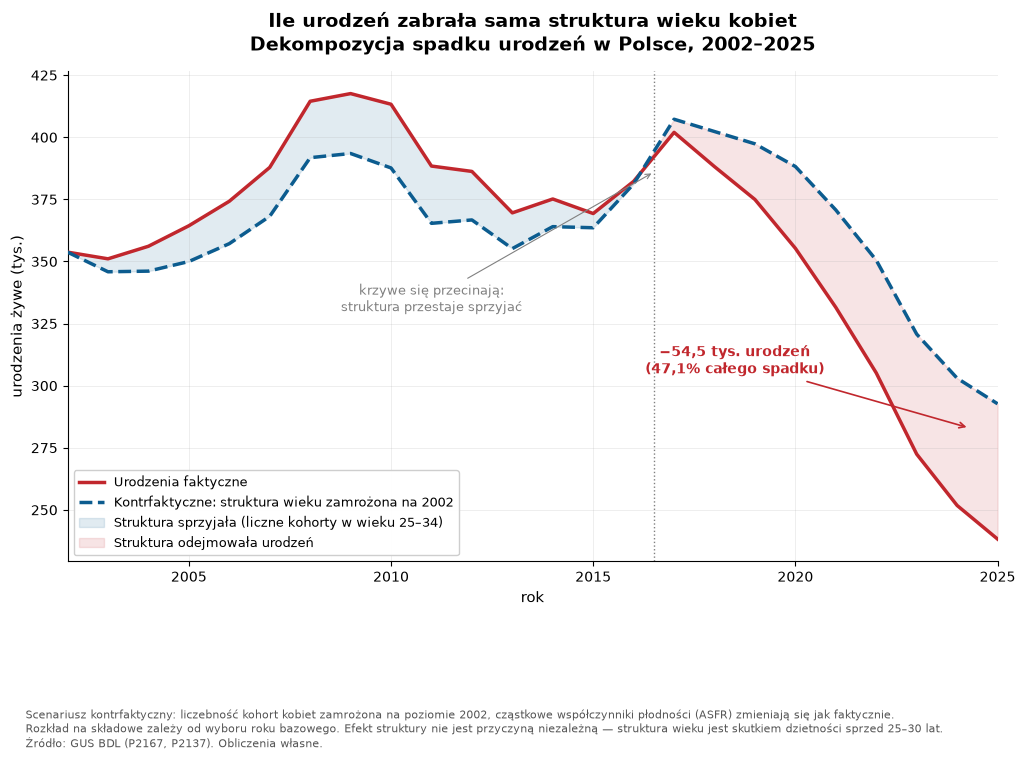

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BAZA = Path.home() / "projekty" / "dzietnosc-polska"
FIGURY = BAZA / "figures"
FIGURY.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 7))

# Dwa scenariusze
ax.plot(dekomp.index, dekomp["faktyczne"] / 1000,
        color="#c1272d", linewidth=2.5, label="Urodzenia faktyczne", zorder=3)
ax.plot(dekomp.index, dekomp["kontrfaktyczne"] / 1000,
        color="#0c5c8f", linewidth=2.5, linestyle="--",
        label="Kontrfaktyczne: struktura wieku zamrożona na 2002", zorder=3)

# Obszar miedzy krzywymi = efekt struktury
ax.fill_between(dekomp.index, dekomp["faktyczne"] / 1000,
                dekomp["kontrfaktyczne"] / 1000,
                where=dekomp["faktyczne"] >= dekomp["kontrfaktyczne"],
                color="#0c5c8f", alpha=0.12, interpolate=True,
                label="Struktura sprzyjała (liczne kohorty w wieku 25–34)")
ax.fill_between(dekomp.index, dekomp["faktyczne"] / 1000,
                dekomp["kontrfaktyczne"] / 1000,
                where=dekomp["faktyczne"] < dekomp["kontrfaktyczne"],
                color="#c1272d", alpha=0.12, interpolate=True,
                label="Struktura odejmowała urodzeń")

# Punkt zmiany znaku
ax.axvline(2016.5, color="gray", linewidth=1, linestyle=":", zorder=1)
ax.annotate("krzywe się przecinają:\nstruktura przestaje sprzyjać",
            xy=(2016.5, 386), xytext=(2011, 330),
            fontsize=9, color="gray", ha="center",
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

# Domkniecie: rozmiar luki w 2025
ax.annotate("−54,5 tys. urodzeń\n(47,1% całego spadku)",
            xy=(2024.3, 283), xytext=(2018.5, 305),
            fontsize=10, color="#c1272d",
            ha="center", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#c1272d", lw=1.2))

ax.set_title("Ile urodzeń zabrała sama struktura wieku kobiet\n"
             "Dekompozycja spadku urodzeń w Polsce, 2002–2025",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("rok", fontsize=11)
ax.set_ylabel("urodzenia żywe (tys.)", fontsize=11)
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
ax.grid(alpha=0.25, linewidth=0.6)
ax.set_xlim(2002, 2025)
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.08, 0.02,
         "Scenariusz kontrfaktyczny: liczebność kohort kobiet zamrożona na poziomie 2002, "
         "cząstkowe współczynniki płodności (ASFR) zmieniają się jak faktycznie.\n"
         "Rozkład na składowe zależy od wyboru roku bazowego. Efekt struktury nie jest "
         "przyczyną niezależną — struktura wieku jest skutkiem dzietności sprzed 25–30 lat.\n"
         "Źródło: GUS BDL (P2167, P2137). Obliczenia własne.",
         fontsize=8, color="#555555", va="bottom")

fig.subplots_adjust(bottom=0.22)
plt.savefig(FIGURY / "06_dekompozycja_urodzen.png", dpi=150)
plt.show()